# Praktikum: t-SNE — Iris & Digits Dataset

Notebook ini mempraktikkan teknik visualisasi **t-SNE** (t-Distributed Stochastic Neighbor Embedding)
dari materi `t-SNE.md`, diterapkan pada dataset **Iris** (150 sampel, 4 fitur) dan **Digits** (1797 sampel, 64 fitur).

Yang dibahas:
- Preprocessing dengan StandardScaler (dan kenapa wajib)
- Efek parameter `perplexity`
- Efek `random_state` (stochastic nature)
- Interpretasi yang benar (common mistakes)
- Visualisasi high-dimensional dataset (Digits, 64 fitur)

## 1. Import Library

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, load_digits
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings("ignore")

## 2. Dataset: Iris

Dataset Iris berisi 150 sampel bunga dari 3 species (*setosa*, *versicolor*, *virginica*),
masing-masing dengan 4 fitur numerik (panjang/lebar sepal dan petal).

Dengan hanya 4 fitur, sebenarnya kita masih bisa pakai pair plot.
Tapi Iris cocok untuk **belajar t-SNE** karena datasetnya kecil dan hasilnya cepat.

In [2]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

print(f"Shape: {X_iris.shape}")
print(f"Fitur: {iris.feature_names}")
print(f"Kelas: {list(iris.target_names)}")
print(f"Distribusi kelas: {np.bincount(y_iris)}")

Shape: (150, 4)
Fitur: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Kelas: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Distribusi kelas: [50 50 50]


## 3. Preprocessing: StandardScaler

t-SNE menghitung **Euclidean distance** antar data points. Kalau fitur punya skala yang beda-beda,
fitur dengan range besar akan **mendominasi** perhitungan jarak — fitur lain jadi "tidak terlihat".

**StandardScaler** mengubah setiap fitur ke mean = 0 dan standard deviation = 1,
sehingga semua fitur punya kontribusi yang setara.

In [3]:
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

print("Sebelum scaling:")
print(f"  Mean per fitur: {X_iris.mean(axis=0).round(2)}")
print(f"  Std per fitur:  {X_iris.std(axis=0).round(2)}")
print()
print("Sesudah scaling:")
print(f"  Mean per fitur: {X_iris_scaled.mean(axis=0).round(2)}")
print(f"  Std per fitur:  {X_iris_scaled.std(axis=0).round(2)}")

Sebelum scaling:
  Mean per fitur: [5.84 3.06 3.76 1.2 ]
  Std per fitur:  [0.83 0.43 1.76 0.76]

Sesudah scaling:
  Mean per fitur: [-0. -0. -0. -0.]
  Std per fitur:  [1. 1. 1. 1.]


> **Penting**: StandardScaler ini **wajib** sebelum t-SNE. Tanpa scaling,
> fitur dengan range besar (misal petal length: 1–7 cm) akan mendominasi
> dibanding fitur dengan range kecil (misal sepal width: 2–4.5 cm).

### Apa Bedanya? Scaled vs Unscaled

Untuk membuktikan kenapa scaling itu penting, mari bandingkan hasil t-SNE
**dengan** dan **tanpa** StandardScaler secara side-by-side.

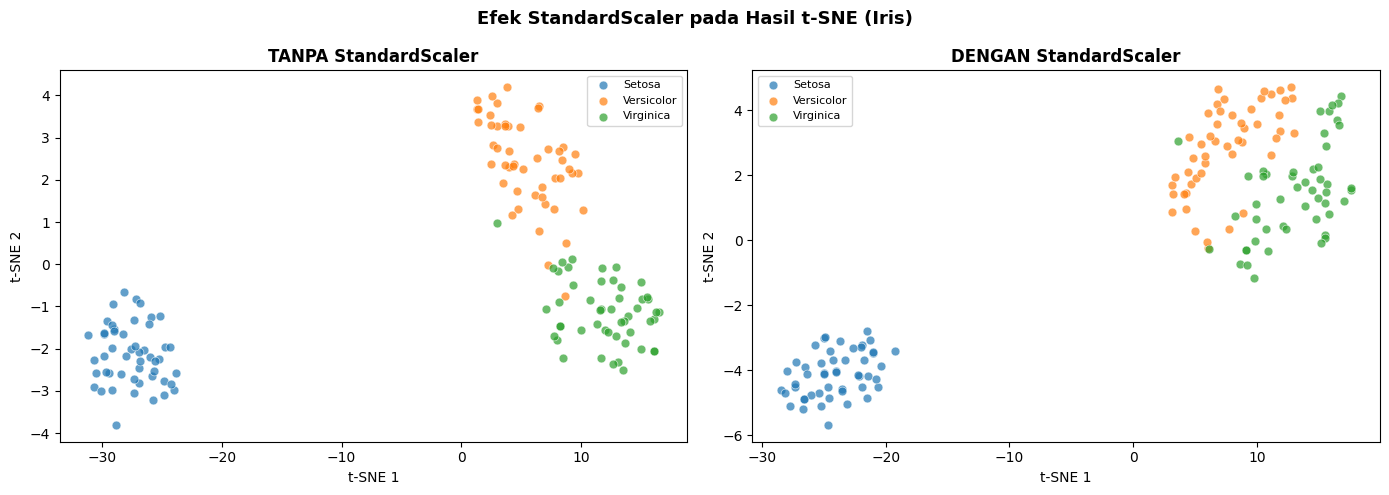

KL Divergence (tanpa scaling): 0.1202
KL Divergence (dengan scaling): 0.1470


In [4]:
# Jalankan t-SNE pada data TANPA scaling
tsne_unscaled = TSNE(n_components=2, perplexity=30, random_state=42)
X_iris_tsne_unscaled = tsne_unscaled.fit_transform(X_iris)

# Jalankan t-SNE pada data DENGAN scaling
tsne_scaled = TSNE(n_components=2, perplexity=30, random_state=42)
X_iris_tsne_scaled = tsne_scaled.fit_transform(X_iris_scaled)

# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, name in enumerate(iris.target_names):
    mask = y_iris == i
    ax1.scatter(X_iris_tsne_unscaled[mask, 0], X_iris_tsne_unscaled[mask, 1],
               alpha=0.7, label=name.capitalize(), s=40,
               edgecolors="white", linewidth=0.5)
    ax2.scatter(X_iris_tsne_scaled[mask, 0], X_iris_tsne_scaled[mask, 1],
               alpha=0.7, label=name.capitalize(), s=40,
               edgecolors="white", linewidth=0.5)

ax1.set_title("TANPA StandardScaler", fontweight="bold")
ax1.set_xlabel("t-SNE 1")
ax1.set_ylabel("t-SNE 2")
ax1.legend(loc="best", fontsize=8)

ax2.set_title("DENGAN StandardScaler", fontweight="bold")
ax2.set_xlabel("t-SNE 1")
ax2.set_ylabel("t-SNE 2")
ax2.legend(loc="best", fontsize=8)

fig.suptitle("Efek StandardScaler pada Hasil t-SNE (Iris)", fontweight="bold", fontsize=13)
fig.tight_layout()
plt.show()

print(f"KL Divergence (tanpa scaling): {tsne_unscaled.kl_divergence_:.4f}")
print(f"KL Divergence (dengan scaling): {tsne_scaled.kl_divergence_:.4f}")

Pada dataset Iris, perbedaannya mungkin tidak terlalu drastis karena range fiturnya
masih relatif mirip (semua dalam cm). Tapi pada dataset dengan mixed scales
(misal: usia 0–100 vs gaji 0–1.000.000), perbedaannya bisa **sangat signifikan** —
fitur gaji akan completely dominate perhitungan jarak.

> **Takeaway**: Selalu pakai StandardScaler sebelum t-SNE. Ini bukan opsional.

## 4. t-SNE Dasar

Jalankan t-SNE dengan commonly used parameters:
- `n_components=2` — reduksi ke 2D untuk visualisasi
- `perplexity=30` — default sklearn, works well untuk most cases
- `random_state=42` — untuk reproducibility

In [5]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_iris_tsne = tsne.fit_transform(X_iris_scaled)

print(f"Shape hasil t-SNE: {X_iris_tsne.shape}")
print(f"KL Divergence: {tsne.kl_divergence_:.4f}")
print(f"Iterasi berjalan: {tsne.n_iter_}")

Shape hasil t-SNE: (150, 2)
KL Divergence: 0.1470
Iterasi berjalan: 999


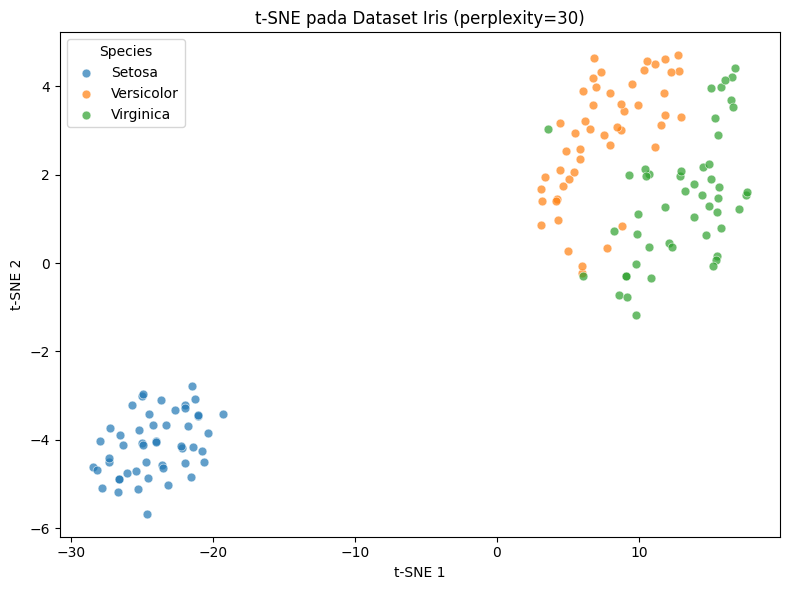

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, name in enumerate(iris.target_names):
    mask = y_iris == i
    ax.scatter(
        X_iris_tsne[mask, 0], X_iris_tsne[mask, 1],
        alpha=0.7, label=name.capitalize(), s=40,
        edgecolors="white", linewidth=0.5
    )
ax.legend(loc="best", title="Species")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE pada Dataset Iris (perplexity=30)")
plt.tight_layout()
plt.show()

**Observasi**:
- **Setosa** terpisah jelas dari dua species lainnya
- **Versicolor** dan **virginica** saling berdekatan — konsisten dengan fakta bahwa keduanya memang punya karakteristik morfologi yang lebih mirip

### Axis X dan Y pada t-SNE Plot

Pertanyaan paling umum: **"Axis X dan Y itu artinya apa?"**

Jawabannya: **tidak ada artinya**. Berbeda dengan PCA di mana PC1 = direction of maximum variance
dan bisa di-interpret lewat loadings, axis di t-SNE:

- **Bukan represent fitur tertentu** — axis X bukan fitur ke-1, axis Y bukan fitur ke-2
- **Unitless** — skala angkanya (misal -40 sampai 40) tidak punya meaning
- **Arbitrary orientation** — plot bisa di-rotate, di-flip, atau di-scale tanpa mengubah informasi apapun

Kenapa? Karena t-SNE hanya mengoptimasi **relative positions** antar data points — bukan posisi absolutnya.
Yang dijaga: **jarak relatif antar titik**, bukan koordinatnya.

> **Maka**: Yang boleh diinterpretasikan hanya **"titik-titik ini dekat satu sama lain"** (similar)
> dan **"titik-titik ini jauh"** (dissimilar secara lokal). Bukan posisi, bukan skala, bukan axis.

Karena itu, cukup beri label axis `t-SNE 1` dan `t-SNE 2` — bukan nama fitur.

## 5. Efek Perplexity

Perplexity mengontrol berapa banyak **effective nearest neighbors** yang dipertimbangkan.
Nilainya mempengaruhi keseimbangan antara local dan global structure.

Bandingkan 4 nilai perplexity: 5, 15, 30, dan 50.

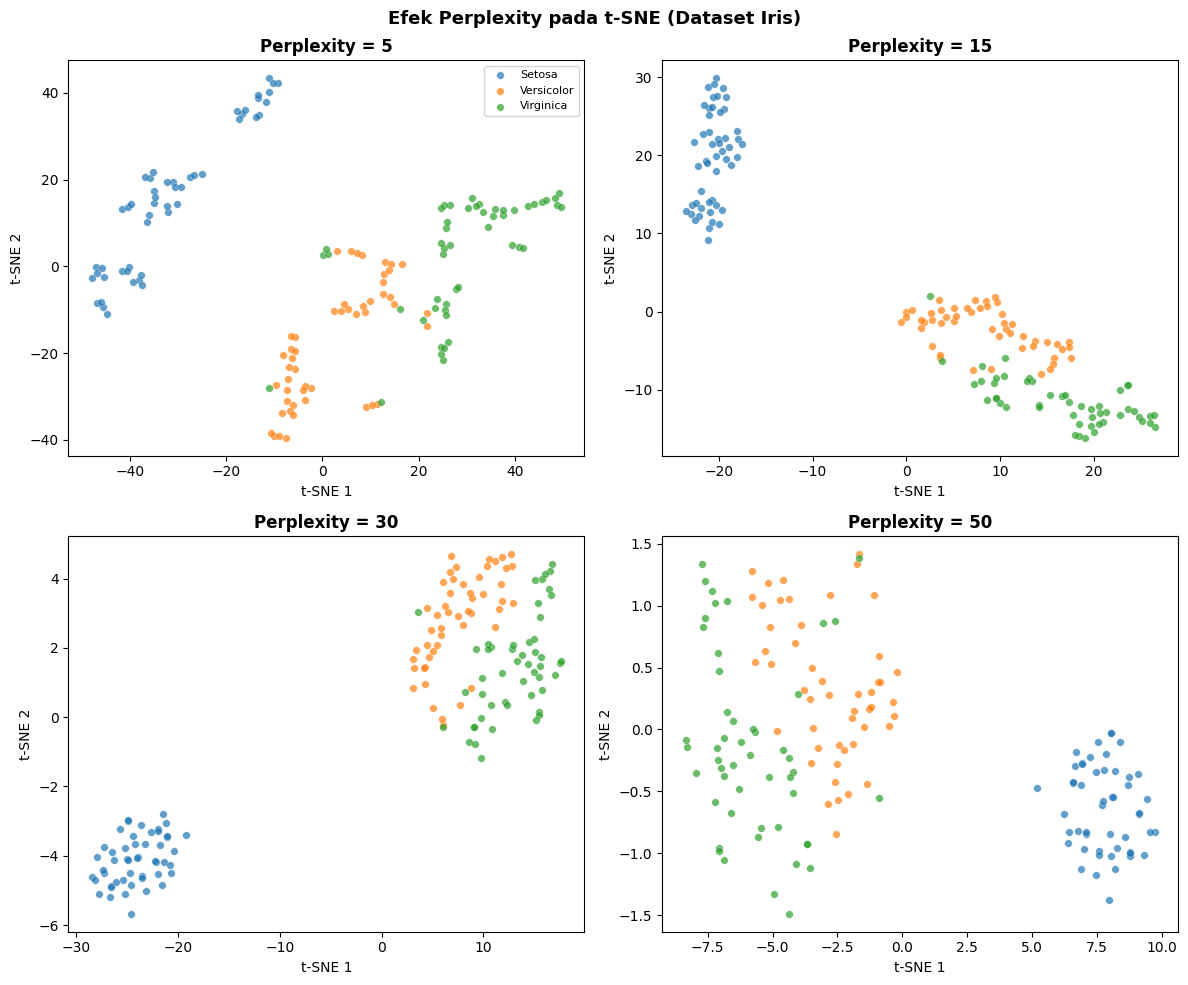

In [7]:
perplexities = [5, 15, 30, 50]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, perp in zip(axes.flat, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X_iris_scaled)

    for i, name in enumerate(iris.target_names):
        mask = y_iris == i
        ax.scatter(
            X_tsne[mask, 0], X_tsne[mask, 1],
            alpha=0.7, label=name.capitalize(), s=30,
            edgecolors="white", linewidth=0.3
        )
    ax.set_title(f"Perplexity = {perp}", fontweight="bold")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

axes[0, 0].legend(loc="best", fontsize=8)
fig.suptitle("Efek Perplexity pada t-SNE (Dataset Iris)", fontweight="bold", fontsize=13)
fig.tight_layout()
plt.show()

**Observasi**:
- **Perplexity 5**: Clusters cenderung pecah jadi sub-clusters kecil — terlalu fokus pada local structure
- **Perplexity 15**: Clusters mulai terbentuk jelas, tapi masih ada sedikit fragmentation
- **Perplexity 30**: Good balance — clusters terlihat kohesif dan well-separated
- **Perplexity 50**: Clusters lebih "menyebar", global structure lebih terasa

Untuk Iris (150 sampel), perplexity 15–30 biasanya memberikan hasil terbaik.
Perplexity harus selalu **lebih kecil dari jumlah data**.

> **Tips**: Dalam praktik, selalu coba minimal 3 nilai perplexity yang berbeda.
> Pattern yang konsisten di berbagai perplexity lebih bisa dipercaya.

## 6. Efek Random State

t-SNE adalah **stochastic** algorithm — hasilnya bisa berbeda tiap kali dijalankan.
Bandingkan 4 random state berbeda dengan perplexity yang sama.

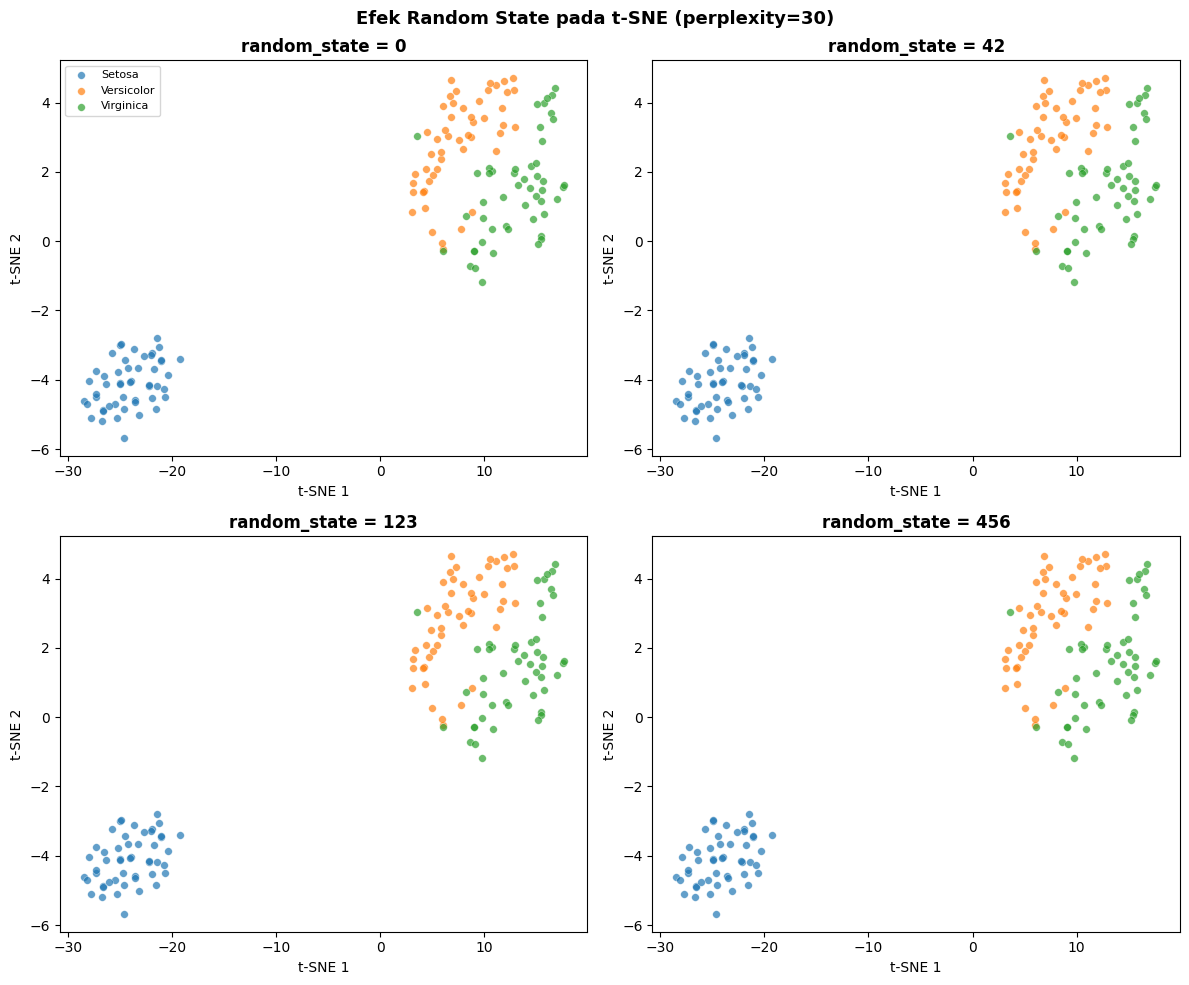

In [8]:
seeds = [0, 42, 123, 456]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, seed in zip(axes.flat, seeds):
    tsne = TSNE(n_components=2, perplexity=30, random_state=seed)
    X_tsne = tsne.fit_transform(X_iris_scaled)

    for i, name in enumerate(iris.target_names):
        mask = y_iris == i
        ax.scatter(
            X_tsne[mask, 0], X_tsne[mask, 1],
            alpha=0.7, label=name.capitalize(), s=30,
            edgecolors="white", linewidth=0.3
        )
    ax.set_title(f"random_state = {seed}", fontweight="bold")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

axes[0, 0].legend(loc="best", fontsize=8)
fig.suptitle("Efek Random State pada t-SNE (perplexity=30)", fontweight="bold", fontsize=13)
fig.tight_layout()
plt.show()

**Observasi**:
- Bentuk dan orientasi clusters **berubah** di setiap run — ini normal
- Tapi **pattern dasarnya konsisten**: setosa selalu terpisah, versicolor–virginica selalu berdekatan
- Posisi dan rotasi clusters bisa berubah karena axis t-SNE memang arbitrary (lihat penjelasan Section 4)

> **Penting**: Jangan pernah conclude dari satu kali run saja.
> Selalu cek apakah pattern konsisten di beberapa random state.
> Kalau cluster muncul di satu seed tapi hilang di seed lain, itu kemungkinan artifact.

## 7. Interpretasi: Benar vs Salah

Ini bagian **terpenting**. Banyak yang membuat interpretation mistakes serius saat membaca t-SNE plot.

### Mistake 1: Cluster Size is Meaningful

**Salah**: "Cluster A lebih besar dari cluster B, berarti A lebih spread out."

**Benar**: Ukuran (area) cluster di t-SNE **tidak** merepresentasikan actual spread.
t-SNE cenderung **equalize cluster density** — cluster yang sangat compact di high-dimensional space
bisa terlihat sama besarnya dengan cluster yang sebenarnya spread out.

### Mistake 2: Inter-Cluster Distance is Meaningful

**Salah**: "Cluster A dan B berdekatan, berarti kedua kelompok itu similar."

**Benar**: Jarak antar clusters di t-SNE **tidak** bisa diinterpretasikan.
Dua clusters yang berdekatan belum tentu lebih similar dibanding yang berjauhan.
t-SNE hanya menjamin local structure (di dalam cluster), bukan global structure (antar clusters).

Kita buktikan ini secara kuantitatif di code cell berikutnya.

### Mistake 3: One Run is Enough

**Salah**: Jalankan t-SNE sekali lalu langsung conclude.

**Benar**: Karena t-SNE itu stochastic, selalu jalankan dengan **beberapa random seeds**
dan pastikan pattern yang terlihat **konsisten** (sudah kita buktikan di Section 6).

> **Ringkasan**:
>
> Yang **boleh** diinterpretasikan:
> - **Keberadaan** clusters — jika titik-titik konsisten mengelompok di beberapa runs
> - **Kedekatan dalam cluster** — titik-titik dalam satu cluster memang similar
>
> Yang **tidak boleh** diinterpretasikan:
> - Ukuran cluster (besar vs kecil)
> - Jarak antar clusters
> - Bentuk cluster (bulat vs memanjang)

In [9]:
# Demonstrasi Mistake 2: jarak antar centroid di t-SNE vs ruang asli
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_iris_scaled)

# Hitung centroid tiap cluster di ruang t-SNE
print("Centroid tiap cluster di ruang t-SNE:")
centroids = []
for i, name in enumerate(iris.target_names):
    mask = y_iris == i
    centroid = X_tsne[mask].mean(axis=0)
    centroids.append(centroid)
    print(f"  {name}: ({centroid[0]:.1f}, {centroid[1]:.1f})")

centroids = np.array(centroids)
dist_tsne = squareform(pdist(centroids))

print("\nJarak antar centroid (t-SNE space):")
for i, name_i in enumerate(iris.target_names):
    for j, name_j in enumerate(iris.target_names):
        if j > i:
            print(f"  {name_i} - {name_j}: {dist_tsne[i, j]:.1f}")

# Bandingkan dengan jarak di ruang asli (scaled)
centroids_orig = []
for i in range(3):
    mask = y_iris == i
    centroids_orig.append(X_iris_scaled[mask].mean(axis=0))
centroids_orig = np.array(centroids_orig)
dist_orig = squareform(pdist(centroids_orig))

print("\nJarak antar centroid (original scaled space):")
for i, name_i in enumerate(iris.target_names):
    for j, name_j in enumerate(iris.target_names):
        if j > i:
            print(f"  {name_i} - {name_j}: {dist_orig[i, j]:.2f}")

print("\n** Perhatikan: urutan jarak bisa berbeda antara t-SNE dan ruang asli!")
print("   Ini membuktikan bahwa inter-cluster distance di t-SNE tidak reliable.")

Centroid tiap cluster di ruang t-SNE:
  setosa: (-24.1, -4.1)
  versicolor: (7.5, 2.8)
  virginica: (13.1, 1.5)

Jarak antar centroid (t-SNE space):
  setosa - versicolor: 32.4
  setosa - virginica: 37.6
  versicolor - virginica: 5.7

Jarak antar centroid (original scaled space):
  setosa - versicolor: 2.85
  setosa - virginica: 3.96
  versicolor - virginica: 1.49

** Perhatikan: urutan jarak bisa berbeda antara t-SNE dan ruang asli!
   Ini membuktikan bahwa inter-cluster distance di t-SNE tidak reliable.


## 8. Dataset: Digits

Sekarang kita coba t-SNE pada dataset yang lebih challenging: **Digits**.
1797 gambar angka tulisan tangan (0–9), masing-masing 8x8 piksel = **64 fitur**.

Ini contoh yang lebih realistis di mana t-SNE benar-benar useful —
mustahil memvisualisasikan 64 dimensi dengan scatter plot biasa.

In [10]:
digits = load_digits()
X_dig, y_dig = digits.data, digits.target

print(f"Shape: {X_dig.shape}")
print(f"Jumlah kelas: {len(np.unique(y_dig))}")
print(f"Distribusi kelas: {np.bincount(y_dig)}")

Shape: (1797, 64)
Jumlah kelas: 10
Distribusi kelas: [178 182 177 183 181 182 181 179 174 180]


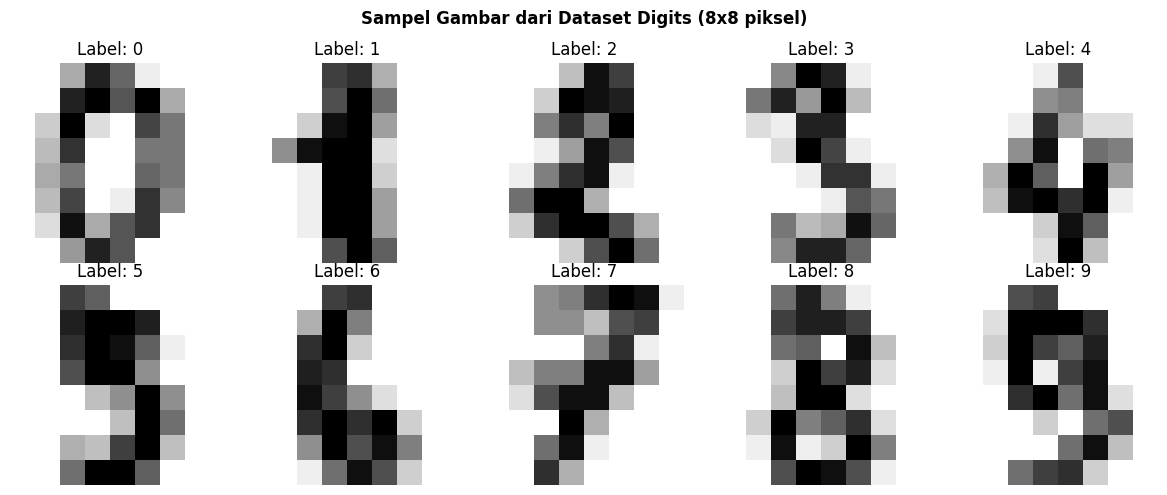

In [11]:
# Tampilkan beberapa sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis("off")
fig.suptitle("Sampel Gambar dari Dataset Digits (8x8 piksel)", fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
# Standarisasi lalu jalankan t-SNE
X_dig_scaled = StandardScaler().fit_transform(X_dig)

tsne_dig = TSNE(n_components=2, perplexity=30, random_state=42)
X_dig_tsne = tsne_dig.fit_transform(X_dig_scaled)

print(f"Shape hasil: {X_dig_tsne.shape}")
print(f"KL Divergence: {tsne_dig.kl_divergence_:.4f}")

Shape hasil: (1797, 2)
KL Divergence: 0.8376


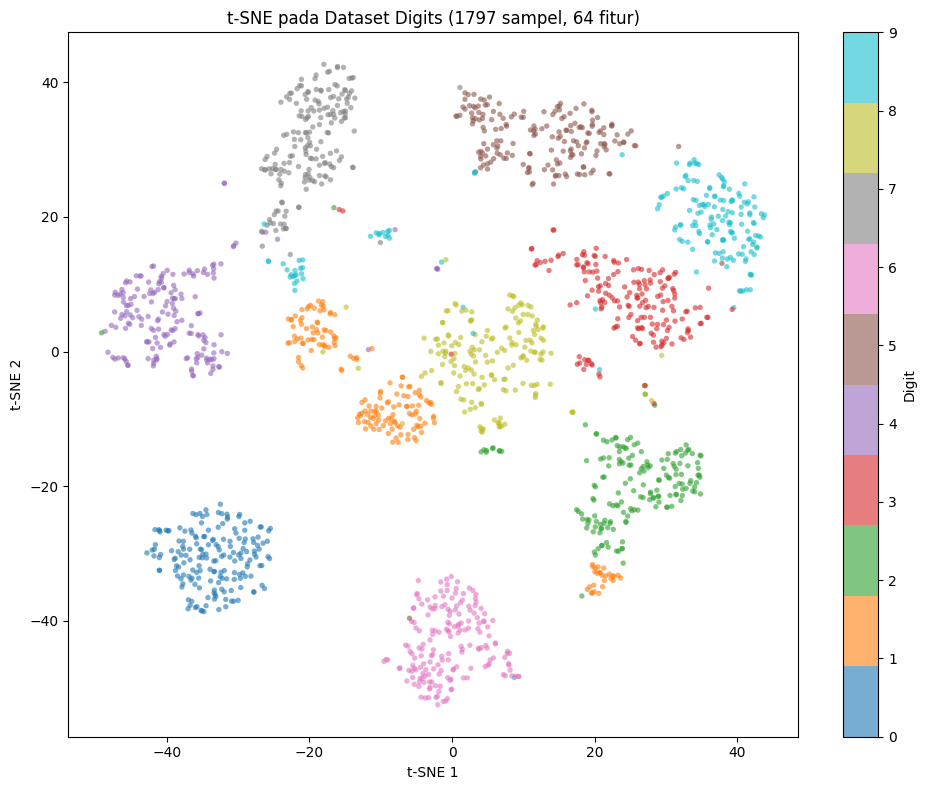

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_dig_tsne[:, 0], X_dig_tsne[:, 1],
    c=y_dig, cmap=plt.cm.tab10,
    alpha=0.6, s=15, edgecolors="none"
)

cbar = fig.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label("Digit")
cbar.ax.set_yticklabels([str(d) for d in range(10)])

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE pada Dataset Digits (1797 sampel, 64 fitur)")
plt.tight_layout()
plt.show()

**Observasi**:
- t-SNE berhasil memisahkan 10 digit menjadi clusters yang cukup jelas
- Beberapa digit (misal 4 dan 9) mungkin sedikit overlap — masuk akal karena
  tulisan tangan 4 dan 9 memang bisa mirip
- Tanpa t-SNE, mustahil memvisualisasikan separasi ini dari 64 fitur

> **Tips**: Nilai `kl_divergence_` yang lebih rendah menunjukkan embedding yang lebih baik.
> Jika nilainya sangat tinggi, coba naikkan `max_iter` atau sesuaikan `perplexity`.

---

## 9. Ringkasan

Apa yang sudah kita pelajari di notebook ini:

| Topik | Key Takeaway |
|---|---|
| StandardScaler | **Wajib** sebelum t-SNE — tanpa scaling, fitur dengan range besar mendominasi |
| t-SNE Dasar | Reduksi high-dimensional data ke 2D untuk visualisasi |
| Axis X/Y | **Tidak punya interpretasi** — unitless, arbitrary orientation |
| Perplexity | Mengontrol jumlah effective neighbors — coba minimal 3 nilai |
| Random State | t-SNE itu stochastic — selalu cek consistency di beberapa seeds |
| Interpretasi | Hanya **keberadaan** clusters yang boleh diinterpretasikan, bukan size/distance/shape |

### Workflow t-SNE

```
Data (n fitur) → StandardScaler → t-SNE (coba 3+ perplexity, 3+ seeds) → Scatter plot → Interpretasi hati-hati
```

Untuk referensi lengkap, baca `t-SNE.md` — terutama bagian limitasi dan cara kerja (KL divergence, distribusi t-Student).